# Personal Information
Name: **Eduard Cruset Pla**

StudentID: **15780627**

Email: [**eduard.cruset.pla@student.uva.nl**](eduard.cruset.pla@student.uva.nl)

Github: [**https://github.com/ecrusetpla/MasterThesis**](https://github.com/ecrusetpla/MasterThesis)

Submitted on: **23.03.2026**


# Data Context
This research integrates high-resolution railway operational data with multi-dimensional socioeconomic and environmental indicators sourced from the **Centraal Bureau voor de Statistiek (CBS)** and the **KNMI**. The dataset provides a daily granular view of the Dutch railway network's performance from 2019 to 2024.

The core of this analysis lies in the merging of four distinct domains:
1. **Railway Operations:** Daily trajectory performance and disruption records sourced from *rijdendetreinen.nl*.
2. **Meteorology:** 10 weather variables from the *KNMI*, mapped to trajectories via the nearest weather station to the source node.
3. **Socioeconomic Status (SES):** Detailed indicators including wealth, education, and employment history. While originally collected by CBS at the neighborhood (*buurt*) level, these have been aggregated to the municipality (*gemeente*) level to represent the broader catchment area of each station.
4. **Urban Proximity & Safety:** Data on the physical distance to essential services (Proximity) and local crime rates (Criminality), providing context on the station's environment.

# Data Description

The dataset consists of daily observations for train trajectories between a **source** and **target** station.

### 1. Operational & Disruption Metrics
* **Rides planned**: The scheduled frequency of the service.
* **Final arrival delay / cancelled**: Performance indicators for reliability.
* **Disruption Count**: Total count of infrastructure or operational failures per day.
* **Statistical Causes**: The classified reason for service failure (e.g., *Defective Train*, *Signal Failure*).

### 2. Meteorological Features (KNMI)
Captured in $0.1$ units (e.g., temperature in $0.1 ^\circ C$, wind in $0.1$ m/s):
* **TG / TN / TX**: Mean, min, and max daily temperature.
* **FHVEC**: Vector mean windspeed.
* **RH / SQ**: Precipitation amount and sunshine duration.

### 3. CBS Socioeconomic Indicators (Municipality Level)
These features represent the average profile of the municipality where the station is located:
* **SES Scores (Wealth, Education, WorkHistory)**: Standardized indices where $0$ represents the national average. Positive values indicate higher-than-average status.
* **Income/Net Worth Percentile**: Relative economic ranking of the municipality's residents.
* **Edu_High / Edu_Low pct**: Percentage of the population with high-level vs. basic educational qualifications.
* **WorkHistory Pct**: Metrics for employment stability (e.g., % constantly employed over 4 years).

### 4. CBS Proximity & Criminality
* **Dist_ [Service]**: Average distance (km) within the municipality to essential facilities (Secondary schools, GP surgeries, Supermarkets, Highway entrances).
* **Criminality Metrics**: (Included in full dataset) Indices for property damage, violence, and theft, serving as a proxy for the social safety of the station's environment.

# Data Description

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import geopandas as gpd
from shapely.geometry import Point
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt


### Data Loading

In [2]:
# Load main dataset
parquet_path = 'C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/processed/final_dataset.parquet'
# Read the parquet file using the fastparquet engine
disruptions_df = pd.read_parquet(parquet_path, engine='fastparquet')
disruptions_df['Date'] = pd.to_datetime(disruptions_df['Date'])

# Load data necessary for graph
coordinates_df = pd.read_csv('C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/geospatial/stations-2023-09-nl.csv')
distances_df = pd.read_csv('C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/geospatial/station_distances.csv')

# Merge distance data
disruptions_df = disruptions_df.merge(
    distances_df, 
    how='left', 
    left_on=['source', 'target'], 
    right_on=['origin_name', 'destination_name']
)
# Strip column names to remove leading/trailing spaces
disruptions_df.columns = disruptions_df.columns.str.strip()
# disruptions_df['distance'] = disruptions_df['distance'].fillna(0)
disruptions_df = disruptions_df.drop(columns=['Unnamed: 0','origin_name', 'destination_name'])
disruptions_df = disruptions_df.dropna(subset=['SQ', 'distance'], how='all')
valid_stations = set(coordinates_df['name_long'])
# Filter out rows where both source and target are not in valid stations
disruptions_df = disruptions_df[~(disruptions_df['distance'].isna() & (~disruptions_df['source'].isin(valid_stations) | ~disruptions_df['target'].isin(valid_stations)))]
# Convert weather columns to float
columns_to_convert = ['DR', 'RH', 'SQ', 'TG', 'TN', 'TX', 'RHX', 'VVX', 'T10N', 'FHVEC']

# Clean the data: strip spaces and coerce non-numeric values to NaN
disruptions_df[columns_to_convert] = disruptions_df[columns_to_convert].map(lambda x: str(x).strip() if isinstance(x, str) else x)
disruptions_df[columns_to_convert] = disruptions_df[columns_to_convert].apply(pd.to_numeric, errors='coerce')

# Check for columns with NaN values
nan_columns = disruptions_df.columns[disruptions_df.isna().any()].tolist()

for col in nan_columns:
    disruptions_df[col] = disruptions_df[col].fillna(disruptions_df[col].median())
# Ensure 'Statistical Causes' is a string before applying eval
disruptions_df['Statistical Causes'] = disruptions_df['Statistical Causes'].apply(
    lambda x: eval(x) if isinstance(x, str) and x != 'No Disruption' else x
)
disruptions_df

c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\EduardCP\Documents\GitHub\MasterThesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keep

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,target_TotalVandalism,target_TotalViolentAndSexualCrimes,target_TotalPropertyCrimes_Rate,target_Dist_Secondary_Total,target_Dist_GP_Surgery,target_Dist_Supermarket,target_Dist_Highway_Entrance,target_Dist_Train_Station_Total,target_Dist_Major_Transfer_Station,distance
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,No Disruption,0.0,...,NaN,NaN,NaN,1.523148,1.122222,0.904630,1.857407,2.245370,3.610185,62.0
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,No Disruption,0.0,...,NaN,NaN,NaN,1.018065,0.746452,0.729677,3.072258,3.429677,4.401290,108.0
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,No Disruption,0.0,...,NaN,NaN,NaN,4.094595,1.540541,1.400000,2.143243,4.013514,12.345946,54.0
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,No Disruption,0.0,...,NaN,NaN,NaN,1.708130,1.154472,0.965854,1.583740,2.098374,3.191870,73.0
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,No Disruption,0.0,...,NaN,NaN,NaN,1.478030,1.012121,0.875758,2.623485,3.403788,3.912121,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,No Disruption,0.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,95.0
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,No Disruption,0.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,201.0
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,No Disruption,0.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,121.0
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,No Disruption,0.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,87.0


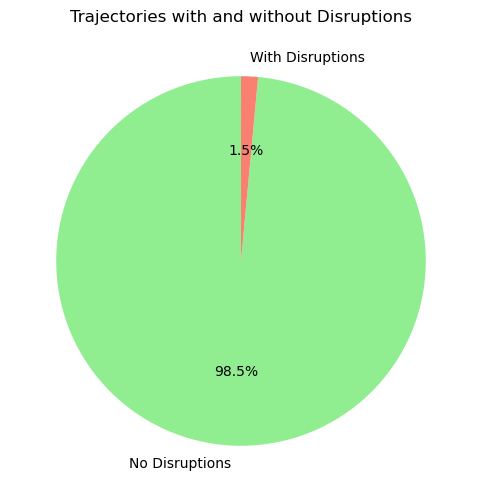

In [3]:
import matplotlib.pyplot as plt

# Count the number of trajectories with Disruption Count == 0 and > 0
disrupted = (disruptions_df["Disrupted"] == True).sum()
non_disrupted =  (disruptions_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [4]:
# Define conditions
# Handle boolean or numeric columns
condition1 = disruptions_df['Final arrival cancelled'].astype(int) > 0  # Convert boolean to int if needed
condition2 = disruptions_df['Completely cancelled'].astype(int) > 0
condition3 = disruptions_df['Disruption Count'] == 0

# Combine conditions
mask = condition1 & condition2 & condition3

# Set Disrupted to True where conditions are met
disruptions_df.loc[mask, 'Disrupted'] = True
disruptions_df.loc[mask, 'Disruption Count'] = disruptions_df['Final arrival cancelled']
disruptions_df.loc[mask, 'Statistical Causes'] = [ ['Unspecified'] for _ in range(mask.sum()) ]

In [5]:
disruptions_df[disruptions_df['Disrupted'] == True] 

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,target_TotalVandalism,target_TotalViolentAndSexualCrimes,target_TotalPropertyCrimes_Rate,target_Dist_Secondary_Total,target_Dist_GP_Surgery,target_Dist_Supermarket,target_Dist_Highway_Entrance,target_Dist_Train_Station_Total,target_Dist_Major_Transfer_Station,distance
5,2019-01-01,'s-Hertogenbosch,Roosendaal,2,0,1,1,0,Unspecified,1.0,...,NaN,NaN,NaN,3.189855,1.288406,1.475362,1.805797,3.844928,4.128986,67.0
6,2019-01-01,'s-Hertogenbosch,Utrecht Centraal,1,0,0,0,1,"[damaged overhead wires, an emergency call]",2.0,...,NaN,NaN,NaN,1.418333,0.819167,0.790833,2.185000,2.095833,4.259167,48.0
72,2019-01-01,Den Haag Centraal,Eindhoven Centraal,32,4,1,1,18,Unspecified,1.0,...,NaN,NaN,NaN,1.478030,1.012121,0.875758,2.623485,3.403788,3.912121,131.0
79,2019-01-01,Den Haag Centraal,Utrecht Centraal,21,2,1,0,4,[broken down train],1.0,...,NaN,NaN,NaN,1.418333,0.819167,0.790833,2.185000,2.095833,4.259167,60.0
101,2019-01-01,Eindhoven Centraal,Den Haag Centraal,32,11,2,2,24,Unspecified,2.0,...,NaN,NaN,NaN,1.018065,0.746452,0.729677,3.072258,3.429677,4.401290,131.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654318,2024-12-31,Lelystad Centrum,Rotterdam Centraal,13,3,1,1,10,Unspecified,1.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,127.0
654361,2024-12-31,Rotterdam Centraal,Lelystad Centrum,15,1,2,2,5,Unspecified,2.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,127.0
654363,2024-12-31,Rotterdam Centraal,Utrecht Centraal,61,11,1,1,37,[broken down train],1.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,56.0
654379,2024-12-31,Uitgeest,Rotterdam Centraal,27,3,1,1,20,Unspecified,1.0,...,NaN,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,86.0


### Data Imbalance

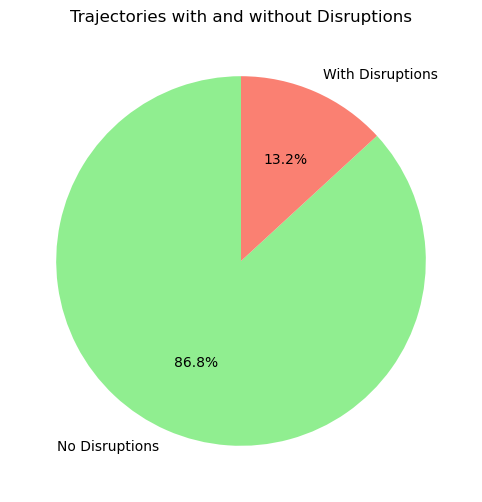

In [6]:
import matplotlib.pyplot as plt

# Count the number of trajectories with Disruption Count == 0 and > 0
disrupted = (disruptions_df["Disrupted"] == True).sum()
non_disrupted =  (disruptions_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

## Most Common Statistical Causes Over Time

C:\Users\EduardCP\AppData\Local\Temp\ipykernel_26460\979378941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disrupted_df['Year'] = pd.to_datetime(disrupted_df['Date']).dt.year


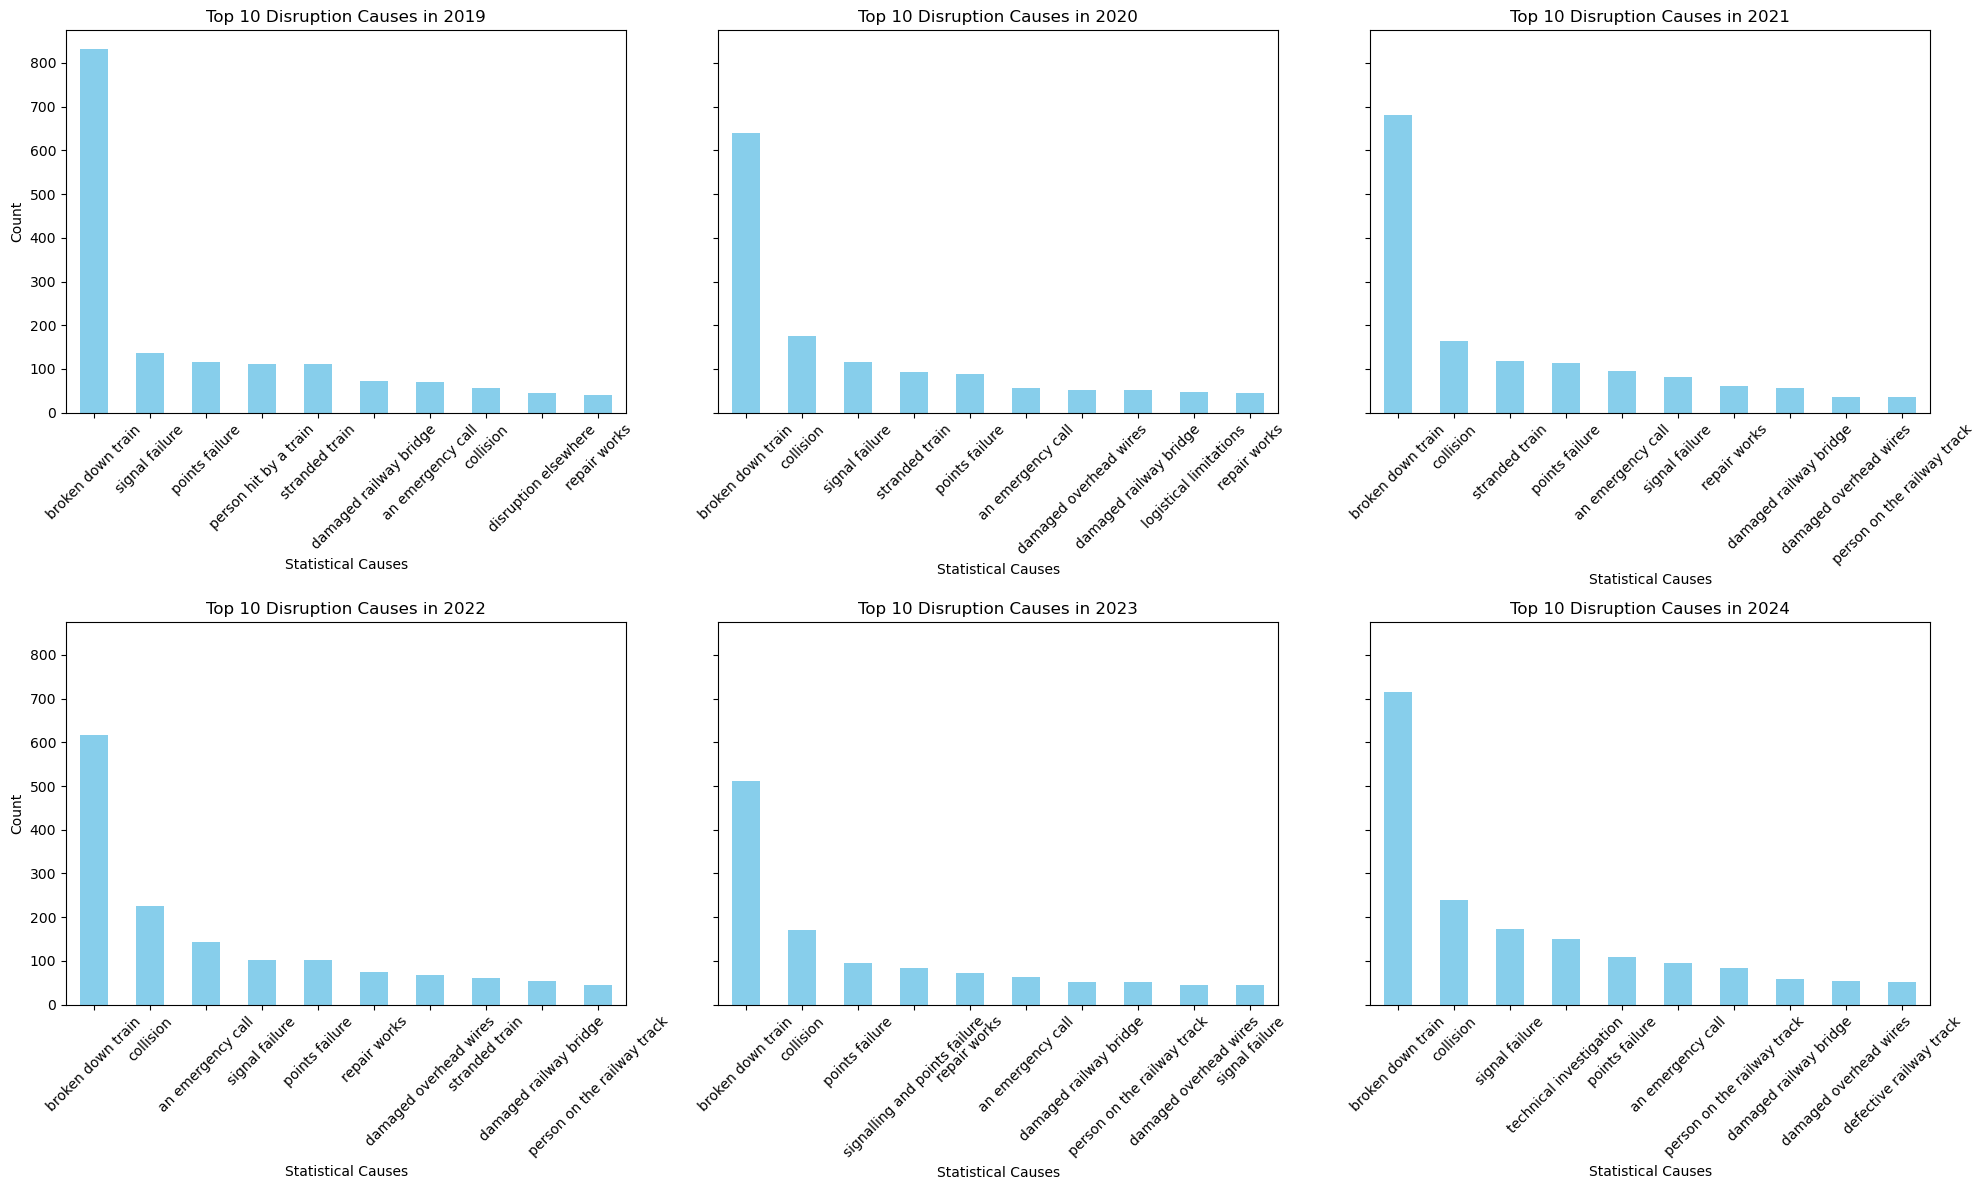

In [7]:
disrupted_df = disruptions_df[disruptions_df['Disrupted'] == True]
disrupted_df['Year'] = pd.to_datetime(disrupted_df['Date']).dt.year

# Explode the 'Statistical Causes' column to separate individual causes
disrupted_df_exploded = disrupted_df.copy()
disrupted_df_exploded = disrupted_df_exploded.explode('Statistical Causes')

# Group by year and cause, then count occurrences
causes_by_year = disrupted_df_exploded.groupby(['Year', 'Statistical Causes']).size().unstack(fill_value=0)

# Create subplots for all years in the same figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), sharey=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each year's data in a separate subplot
for i, year in enumerate(causes_by_year.index):
    ax = axes[i]
    causes_by_year.loc[year].nlargest(11).iloc[1:].sort_values(ascending=False).plot(kind='bar', color='skyblue', ax=ax)
    ax.set_title(f'Top 10 Disruption Causes in {year}')
    ax.set_xlabel('Statistical Causes')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

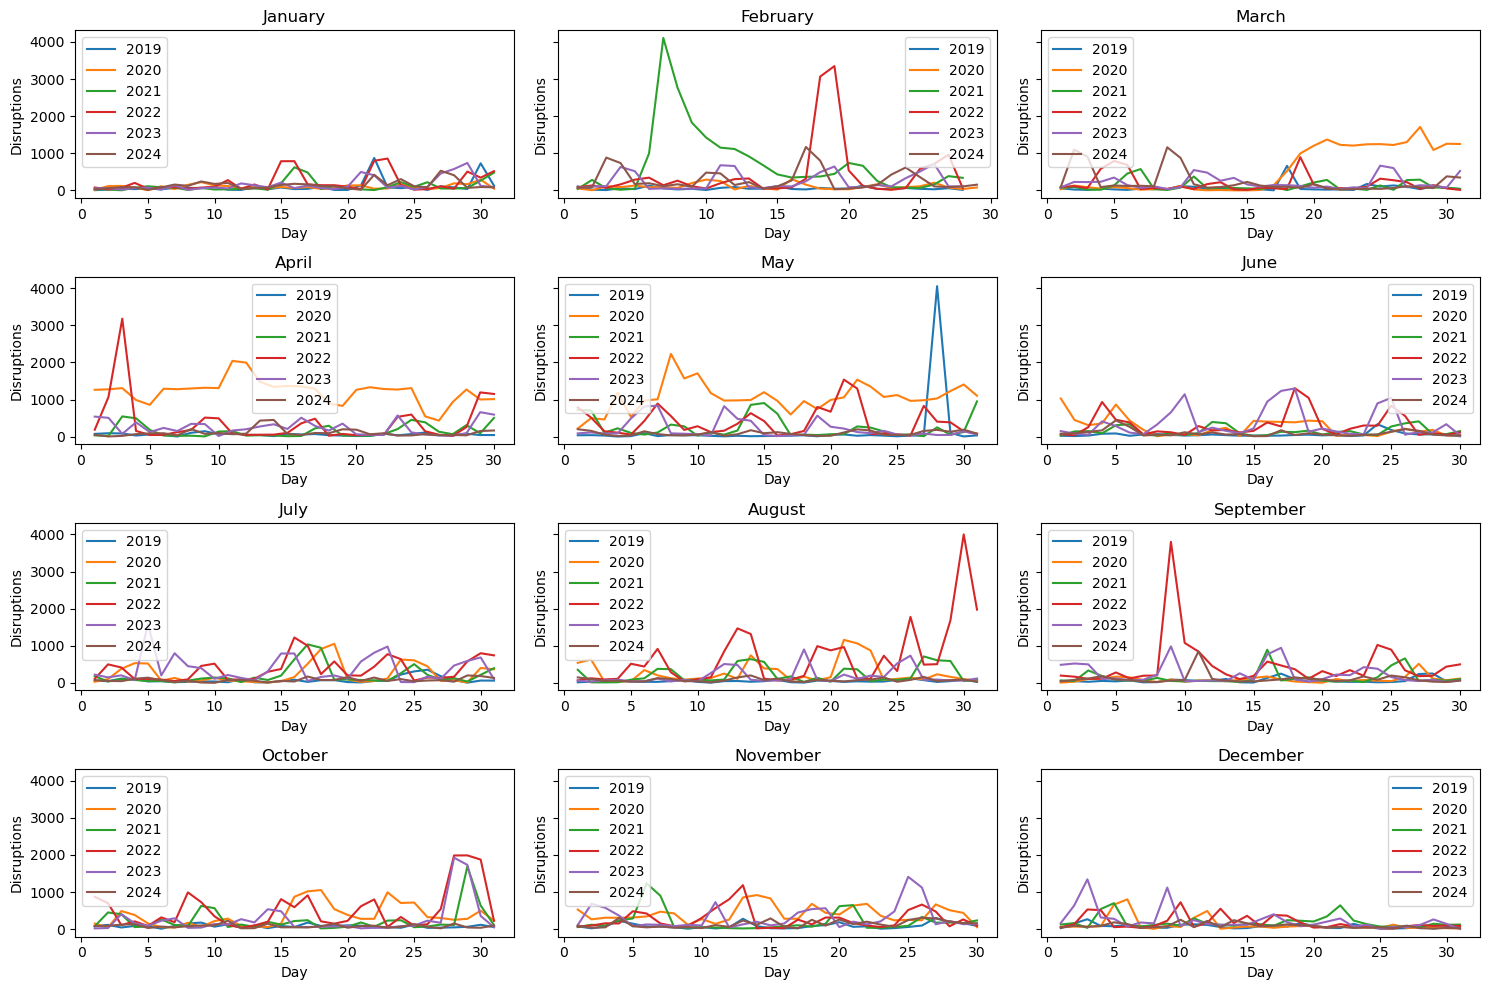

In [8]:
disruptions_df['Year'] = disruptions_df['Date'].dt.year
disruptions_df['Month'] = disruptions_df['Date'].dt.month
disruptions_df['Day'] = disruptions_df['Date'].dt.day
daily_by_year_month = disruptions_df.groupby(['Year', 'Month', 'Day'])['Disruption Count'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharey=True)
axes = axes.flatten()
months = range(1, 13)
for i, month in enumerate(months):
    month_data = disruptions_df[disruptions_df['Date'].dt.month == month]
    for year in month_data['Year'].unique():
        year_month_data = month_data[month_data['Year'] == year]
        daily = year_month_data.groupby(year_month_data['Date'].dt.day)['Disruption Count'].sum()
        axes[i].plot(daily.index, daily.values, label=f'{year}')
    months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
    axes[i].set_title(f'{months[month - 1]}')
    axes[i].set_xlabel('Day')
    axes[i].set_ylabel('Disruptions')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [9]:
disruptions_by_year = disruptions_df.groupby('Year')[[ 'Disruption Count', 'Rides planned']].sum()
disruptions_by_year

,Disruption Count,Rides planned
Year,,
2019,29662.0,1482439
2020,147899.0,1554725
2021,82179.0,1480284
2022,135717.0,1567080
2023,93242.0,1412076
2024,47347.0,1493475


In [10]:
disruptions_by_month = disruptions_df.groupby('Month')['Disruption Count'].sum()
disruptions_by_month

Month
1     26514.0
2     52868.0
3     43378.0
4     65137.0
5     67619.0
6     36933.0
7     42055.0
8     47024.0
9     34424.0
10    48498.0
11    43635.0
12    27961.0
Name: Disruption Count, dtype: float64

In [11]:
# Assuming disruptions_df is already defined with 'Date' and 'Disruption Count' columns
disruptions_df['Year'] = disruptions_df['Date'].dt.year
disruptions_df['Month'] = disruptions_df['Date'].dt.month
disruptions_df['Day'] = disruptions_df['Date'].dt.day

# Define seasons based on date ranges
def get_season(date):
    if (date.month == 12 and date.day >= 21) or (date.month <= 3 and date.day <= 20):
        return 'Winter'
    elif (date.month == 3 and date.day >= 21) or (date.month <= 6 and date.day <= 20):
        return 'Spring'
    elif (date.month == 6 and date.day >= 21) or (date.month <= 9 and date.day <= 20):
        return 'Summer'
    elif (date.month == 9 and date.day >= 21) or (date.month <= 12 and date.day <= 20):
        return 'Autumn'

disruptions_df['Season'] = disruptions_df['Date'].apply(get_season)
disruptions_by_season = disruptions_df.groupby('Season')[['Disruption Count', 'Rides planned']].sum()
disruptions_by_season['Proportion'] = disruptions_by_season['Disruption Count'] / disruptions_by_season['Rides planned']
disruptions_by_season

,Disruption Count,Rides planned,Proportion
Season,,,
Autumn,85936.0,1719680,0.049972
Spring,134061.0,1730142,0.077486
Summer,81966.0,1790431,0.045780
Winter,82758.0,1607318,0.051488


## Outliers

In [12]:
top_10_disruptions = disruptions_df.sort_values(by='Disruption Count', ascending=False)[['Date','source', 'target', 'Disruption Count']].head(10)
top_10_disruptions

,Date,source,target,Disruption Count
302851,2021-10-29,Eindhoven Centraal,Boxtel,375.0
302797,2021-10-29,Boxtel,Eindhoven Centraal,373.0
225651,2021-02-07,Amsterdam Sloterdijk,Zaandam,346.0
225817,2021-02-07,Zaandam,Amsterdam Sloterdijk,315.0
345794,2022-03-19,Leiden Centraal,Schiphol Airport,288.0
345847,2022-03-19,Schiphol Airport,Leiden Centraal,281.0
392892,2022-08-19,Boxtel,Eindhoven Centraal,281.0
390777,2022-08-12,Boxtel,Eindhoven Centraal,278.0
447668,2023-02-18,Nijmegen,Arnhem Centraal,261.0
367311,2022-05-27,Amersfoort Centraal,Utrecht Centraal,254.0


In [13]:
summed_disruptions = disruptions_df.groupby(['source', 'target'])[[ 'Rides planned', 'Disruption Count']].sum().reset_index()
summed_disruptions = summed_disruptions.sort_values(by='Disruption Count', ascending=False)

# Display the top 10 most disrupted trajectories
summed_disruptions.head(10)

,source,target,Rides planned,Disruption Count
3557,Rotterdam Centraal,Amsterdam Centraal,78784,9925.0
605,Amsterdam Centraal,Rotterdam Centraal,73825,8522.0
1939,Eindhoven Centraal,Den Haag Centraal,67331,6945.0
539,Amsterdam Centraal,Breda,54130,5569.0
1381,Den Haag Centraal,Amsterdam Centraal,101534,5371.0
546,Amsterdam Centraal,Den Haag Centraal,103254,5323.0
1408,Den Haag Centraal,Eindhoven Centraal,65794,5320.0
1178,Breda,Amsterdam Centraal,53981,5315.0
216,Almere Centrum,Amsterdam Centraal,69873,4937.0
4159,Utrecht Centraal,Rotterdam Centraal,63434,4850.0


In [14]:
# Display the 10 least disrupted trajectories
no_disruptions = summed_disruptions[summed_disruptions['Disruption Count'] == 0]
no_disruptions = no_disruptions.sort_values(by='Rides planned', ascending=False)
no_disruptions.head(10)

,source,target,Rides planned,Disruption Count
38,'s-Hertogenbosch,Leiden Centraal,11865,0.0
3761,Schiedam Centrum,Rotterdam Blaak,3190,0.0
340,Amersfoort Centraal,Driebergen-Zeist,2817,0.0
1795,Driebergen-Zeist,Amersfoort Centraal,2780,0.0
3747,Schiedam Centrum,Delft Campus,2150,0.0
1354,Delft Campus,Schiedam Centrum,2102,0.0
1715,Dieren,Zwolle,1105,0.0
4774,Zwolle,Dieren,1097,0.0
3057,Maastricht,Roermond,1058,0.0
2918,Leiden Centraal,Heemstede-Aerdenhout,1016,0.0


### Adding Operational Features
- Days (with planned rides) since last disruption (int) </br>
- Total disruptions of this trajectory (int) </br>
- Total rides planned of this trajectory (int) </br>
- Total amount of previous disruptions (int) </br>

- Causes of previous disruptions (list) -onehot-> (array) </br>
- Cause(s) of most recent disruption (list) -onehot-> (array) </br>

In [15]:
# Calculate the value counts of 'Statistical Causes'
cause_counts = disrupted_df_exploded['Statistical Causes'].value_counts()
median = np.median(cause_counts)
st_dev = np.std(cause_counts)
print(median)
print(st_dev)

# Calculate the threshold for causes with counts less than 1.5 standard deviations from the median
high_threshold = median + 1.5 * st_dev
low_threshold = median - 1.5 * st_dev

# Filter causes that fall above this threshold
high_count_causes = cause_counts[cause_counts > high_threshold].index.tolist()

print(high_count_causes)

low_count_causes = cause_counts[cause_counts < low_threshold].index.tolist()
print(low_count_causes)

27.5
8152.411971862569
['Unspecified']
[]


In [16]:
disrupted_df

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,target_TotalViolentAndSexualCrimes,target_TotalPropertyCrimes_Rate,target_Dist_Secondary_Total,target_Dist_GP_Surgery,target_Dist_Supermarket,target_Dist_Highway_Entrance,target_Dist_Train_Station_Total,target_Dist_Major_Transfer_Station,distance,Year
5,2019-01-01,'s-Hertogenbosch,Roosendaal,2,0,1,1,0,Unspecified,1.0,...,NaN,NaN,3.189855,1.288406,1.475362,1.805797,3.844928,4.128986,67.0,2019
6,2019-01-01,'s-Hertogenbosch,Utrecht Centraal,1,0,0,0,1,"[damaged overhead wires, an emergency call]",2.0,...,NaN,NaN,1.418333,0.819167,0.790833,2.185000,2.095833,4.259167,48.0,2019
72,2019-01-01,Den Haag Centraal,Eindhoven Centraal,32,4,1,1,18,Unspecified,1.0,...,NaN,NaN,1.478030,1.012121,0.875758,2.623485,3.403788,3.912121,131.0,2019
79,2019-01-01,Den Haag Centraal,Utrecht Centraal,21,2,1,0,4,[broken down train],1.0,...,NaN,NaN,1.418333,0.819167,0.790833,2.185000,2.095833,4.259167,60.0,2019
101,2019-01-01,Eindhoven Centraal,Den Haag Centraal,32,11,2,2,24,Unspecified,2.0,...,NaN,NaN,1.018065,0.746452,0.729677,3.072258,3.429677,4.401290,131.0,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654318,2024-12-31,Lelystad Centrum,Rotterdam Centraal,13,3,1,1,10,Unspecified,1.0,...,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,127.0,2024
654361,2024-12-31,Rotterdam Centraal,Lelystad Centrum,15,1,2,2,5,Unspecified,2.0,...,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,127.0,2024
654363,2024-12-31,Rotterdam Centraal,Utrecht Centraal,61,11,1,1,37,[broken down train],1.0,...,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,56.0,2024
654379,2024-12-31,Uitgeest,Rotterdam Centraal,27,3,1,1,20,Unspecified,1.0,...,NaN,NaN,3.555734,1.695079,1.578807,2.008171,5.963448,13.379274,86.0,2024


In [17]:
# 1. Days since last disruption and total disruptions for each source-target pair
def days_since_last_disruption_per_pair(df):
    # Initialize columns
    df['Days_since_last_disruption'] = 0
    df['Num_prev_disruptions'] = 0
    df['Ratio'] = 0.0
    
    # Group by source and target
    grouped = df.groupby(['source', 'target'])
    
    for (source, target), group in grouped:
        # Get unique dates, disruption status, and sums
        date_disruption = group.groupby('Date').agg({
            'Disrupted': 'any',
            'Disruption Count': 'sum',
            'Rides planned': 'sum'
        }).reset_index()
        date_disruption['Date'] = pd.to_datetime(date_disruption['Date'])
        
        # Initialize variables
        days_with_rides = 0
        num_disruptions = 0
        total_rides = 0
        last_disruption_date = None
        days_since = []
        total_disr = []
        ratios = []
        
        # Process each unique date
        for _, row in date_disruption.iterrows():
            date = row['Date']
            is_disrupted = row['Disrupted']
            disruption_count = row['Disruption Count'] or 0
            rides_planned = row['Rides planned'] or 0
            
            # Append current cumulative disruptions and ratio (before updating)
            total_disr.append(num_disruptions)
            total_rides += rides_planned
            ratio = (num_disruptions / total_rides * 100) if total_rides > 0 else 0
            ratios.append(ratio)
            
            # Update days counter
            if last_disruption_date is not None:
                days_with_rides += 1
            days_since.append(days_with_rides)
            
            # Update disruption count and reset days if disrupted
            if is_disrupted:
                num_disruptions += disruption_count
                last_disruption_date = date
                days_with_rides = 0
        
        # Map values back to original group rows
        date_to_days = dict(zip(date_disruption['Date'], days_since))
        date_to_disr = dict(zip(date_disruption['Date'], total_disr))
        date_to_ratio = dict(zip(date_disruption['Date'], ratios))
        
        # Assign to DataFrame
        df.loc[group.index, 'Days_since_last_disruption'] = group['Date'].map(date_to_days)
        df.loc[group.index, 'Num_prev_disruptions'] = group['Date'].map(date_to_disr)
        df.loc[group.index, 'Ratio'] = group['Date'].map(date_to_ratio)
    
    return df

disruptions_df = days_since_last_disruption_per_pair(disruptions_df)

In [18]:
# 2. Total disruptions for each source-target pair
def total_disruptions_per_pair(df):
    # Initialize column
    df['Total_disruptions'] = 0
    
    # Group by source and target
    for (source, target), group in df.groupby(['source', 'target']):
        # Compute cumulative sum of disruptions for this pair
        cumsum_disruptions = group['Disruption Count'].cumsum()
        # Assign back to the DataFrame
        df.loc[group.index, 'Total_disruptions'] = cumsum_disruptions
        
    return df

disruptions_df = total_disruptions_per_pair(disruptions_df)

In [19]:
# 3. Total rides planned for each source-target pair
def total_rides_planned_per_pair(df):
    # Initialize column
    df['Total_rides'] = 0
    
    # Group by source and target
    for (source, target), group in df.groupby(['source', 'target']):
        # Compute cumulative sum of disruptions for this pair
        cumsum_disruptions = group['Rides planned'].cumsum()
        # Assign back to the DataFrame
        df.loc[group.index, 'Total_rides'] = cumsum_disruptions
        
    return df

disruptions_df = total_rides_planned_per_pair(disruptions_df)

In [20]:
disruptions_df

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,distance,Year,Month,Day,Season,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,No Disruption,0.0,...,62.0,2019,1,1,Winter,0,0,0.000000,0,1
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,No Disruption,0.0,...,108.0,2019,1,1,Winter,0,0,0.000000,0,33
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,No Disruption,0.0,...,54.0,2019,1,1,Winter,0,0,0.000000,0,17
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,No Disruption,0.0,...,73.0,2019,1,1,Winter,0,0,0.000000,0,11
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,No Disruption,0.0,...,32.0,2019,1,1,Winter,0,0,0.000000,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,No Disruption,0.0,...,95.0,2024,12,31,Winter,34,41,1.379542,41,2972
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,No Disruption,0.0,...,201.0,2024,12,31,Winter,9,2808,4.398427,2808,63841
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,No Disruption,0.0,...,121.0,2024,12,31,Winter,0,0,0.000000,0,43
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,No Disruption,0.0,...,87.0,2024,12,31,Winter,12,1523,2.090798,1523,72843


In [21]:
# Normalize Statistical Causes to always be a list
def normalize_causes(causes):
    if isinstance(causes, str):
        return [causes]
    if isinstance(causes, list):
        return causes
    return []

disruptions_df['Statistical Causes'] = disruptions_df['Statistical Causes'].apply(normalize_causes)

# 3 & 4. Causes of previous disruptions and most recent disruption
all_causes = set()
for causes in disruptions_df['Statistical Causes']:
    all_causes.update(causes)
all_causes = list(all_causes)

# 3 & 4. Causes of previous disruptions and most recent disruption, grouped by source-target
# Initialize columns
disruptions_df['Previous_causes'] = [[] for _ in range(len(disruptions_df))]
disruptions_df['Most_recent_causes'] = [[] for _ in range(len(disruptions_df))]


# Group by source and target
grouped = disruptions_df.groupby(['source', 'target'])

for (source, target), group in grouped:
    previous_causes = []
    most_recent_causes = []
    
    for i, (idx, row) in enumerate(group.iterrows()):
        if i == 0:
            disruptions_df.at[idx, 'Previous_causes'] = []
            disruptions_df.at[idx, 'Most_recent_causes'] = row['Statistical Causes'] if row['Disrupted'] else []
        else:
            disruptions_df.at[idx, 'Previous_causes'] = previous_causes.copy()
            disruptions_df.at[idx, 'Most_recent_causes'] = most_recent_causes.copy()
        
        if row['Disrupted']:
            current_causes = row['Statistical Causes']
            previous_causes.extend(current_causes)
            most_recent_causes = current_causes
    
    # Ensure Previous_causes is unique within the group
    disruptions_df.loc[group.index, 'Previous_causes'] = disruptions_df.loc[group.index, 'Previous_causes'].apply(lambda x: list(set(x)))

disruptions_df

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,Month,Day,Season,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes,Most_recent_causes
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,[No Disruption],0.0,...,1,1,Winter,0,0,0.000000,0,1,[],[]
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,[No Disruption],0.0,...,1,1,Winter,0,0,0.000000,0,33,[],[]
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,[No Disruption],0.0,...,1,1,Winter,0,0,0.000000,0,17,[],[]
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,[No Disruption],0.0,...,1,1,Winter,0,0,0.000000,0,11,[],[]
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,[No Disruption],0.0,...,1,1,Winter,0,0,0.000000,0,18,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,[No Disruption],0.0,...,12,31,Winter,34,41,1.379542,41,2972,[Unspecified],[Unspecified]
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,[No Disruption],0.0,...,12,31,Winter,9,2808,4.398427,2808,63841,[Unspecified],[Unspecified]
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,[No Disruption],0.0,...,12,31,Winter,0,0,0.000000,0,43,[],[]
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,[No Disruption],0.0,...,12,31,Winter,12,1523,2.090798,1523,72843,[Unspecified],[Unspecified]


In [22]:
causes = dict()
for cause in all_causes:
    causes[cause] = np.zeros(len(all_causes))
for i, cause in enumerate(all_causes):
    causes[cause][i] = 1

def causes_to_array(df):
    df['Previous_causes_vec'] = df['Previous_causes'].apply(lambda x: sum([causes[cause] for cause in x]) if len(x) > 0 else np.zeros(len(all_causes)))
    df['Most_recent_causes_vec'] = df['Most_recent_causes'].apply(lambda x: sum([causes[cause] for cause in x]) if len(x) > 0 else np.zeros(len(all_causes)))
    return df
disruptions_df = causes_to_array(disruptions_df)
disruptions_df

,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,Season,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes,Most_recent_causes,Previous_causes_vec,Most_recent_causes_vec
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,[No Disruption],0.0,...,Winter,0,0,0.000000,0,1,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,[No Disruption],0.0,...,Winter,0,0,0.000000,0,33,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,[No Disruption],0.0,...,Winter,0,0,0.000000,0,17,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,[No Disruption],0.0,...,Winter,0,0,0.000000,0,11,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,[No Disruption],0.0,...,Winter,0,0,0.000000,0,18,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,[No Disruption],0.0,...,Winter,34,41,1.379542,41,2972,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,[No Disruption],0.0,...,Winter,9,2808,4.398427,2808,63841,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,[No Disruption],0.0,...,Winter,0,0,0.000000,0,43,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,[No Disruption],0.0,...,Winter,12,1523,2.090798,1523,72843,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [23]:
print(np.mean(disruptions_df['Ratio']))
print(np.std(disruptions_df['Ratio']))
disruptions_df

4.8822604714835585
5.954551001238397


,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,Season,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes,Most_recent_causes,Previous_causes_vec,Most_recent_causes_vec
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,[No Disruption],0.0,...,Winter,0,0,0.000000,0,1,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,[No Disruption],0.0,...,Winter,0,0,0.000000,0,33,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,[No Disruption],0.0,...,Winter,0,0,0.000000,0,17,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,[No Disruption],0.0,...,Winter,0,0,0.000000,0,11,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,[No Disruption],0.0,...,Winter,0,0,0.000000,0,18,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,[No Disruption],0.0,...,Winter,34,41,1.379542,41,2972,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,[No Disruption],0.0,...,Winter,9,2808,4.398427,2808,63841,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,[No Disruption],0.0,...,Winter,0,0,0.000000,0,43,[],[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,[No Disruption],0.0,...,Winter,12,1523,2.090798,1523,72843,[Unspecified],[Unspecified],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [24]:
never_disrupted = disruptions_df[disruptions_df['Total_disruptions'] == 0]
print(never_disrupted)
print("Mean and median of rides planned for never disrupted trajectories:")
print(np.mean(never_disrupted['Total_rides']))
print(np.median(never_disrupted['Total_rides']))
print("Mean and median of rides planned for disrupted trajectories:")
print(np.mean(disruptions_df[disruptions_df['Total_disruptions'] > 0]['Total_rides']))
print(np.median(disruptions_df[disruptions_df['Total_disruptions'] > 0]['Total_rides']))
print("Percentage of never disrupted trajectories:")


             Date            source              target  Rides planned  \
0      2019-01-01  's-Hertogenbosch     Arnhem Centraal              1   
1      2019-01-01  's-Hertogenbosch   Den Haag Centraal             33   
2      2019-01-01  's-Hertogenbosch              Deurne             17   
3      2019-01-01  's-Hertogenbosch           Dordrecht             11   
4      2019-01-01  's-Hertogenbosch  Eindhoven Centraal             18   
...           ...               ...                 ...            ...   
654328 2024-12-31        Maastricht    Utrecht Centraal              2   
654371 2024-12-31  Schiphol Airport              Zwolle              2   
654399 2024-12-31              Velp             Zutphen              1   
654404 2024-12-31             Venlo    Utrecht Centraal              1   
654433 2024-12-31            Zwolle    Schiphol Airport              1   

        Final arrival delay  Final arrival cancelled  Completely cancelled  \
0                         0      

In [25]:
operational_cols = ['Date', 'source', 'target', 'Days_since_last_disruption', 'Num_prev_disruptions', 'Ratio', 'Total_disruptions', 'Total_rides', 'Previous_causes_vec', 'Most_recent_causes_vec']
operational_df = disruptions_df[operational_cols]
operational_df.set_index('Date', inplace=True)

### Graph of the overall Network with all  Possible Edges

In [26]:
import plotly.graph_objects as go
import networkx as nx

sources = disruptions_df['source'].unique()
coordinates_df = pd.read_csv('C:/Users/EduardCP/Documents/GitHub/MasterThesis/data/geospatial/stations-2023-09-nl.csv')
destinations = disruptions_df['target'].unique()
stations = list(set(sources).union(set(destinations)))
edges = disruptions_df[['source', 'target']].values

G = nx.Graph()
G.add_nodes_from(stations)
G.add_edges_from(edges)

# Create a Plotly figure
# Filter coordinates_df to include only stations present in the graph
coordinates_df = coordinates_df[coordinates_df['name_long'].isin(G.nodes())]

# Create a dictionary of positions based on coordinates
pos = {row['name_long']: (row['geo_lng'], row['geo_lat']) for _, row in coordinates_df.iterrows()}

# Remove nodes from the graph that are not in the coordinates_df
nodes_to_remove = [node for node in G.nodes() if node not in pos]
G.remove_nodes_from(nodes_to_remove)

# Extract edge positions
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

# Create edge trace
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# Extract node positions and attributes
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Create node trace
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        size=10,
        colorbar=dict(
            thickness=15,
            title=dict(
                text='Node Connections',
                side='right'
            ),
            xanchor='left'
        )
    )
)

# Add node text
node_adjacencies = []
node_text = []
for node, adjacencies in G.adjacency():
    node_adjacencies.append(len(adjacencies))
    node_text.append(f'{node}<br># of connections: {len(adjacencies)}')

node_trace.marker.color = node_adjacencies
node_trace.text = node_text

# Create the figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Network Graph',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=0, l=0, r=0, t=0),
                    xaxis=dict(showgrid=False, zeroline=False),
                    yaxis=dict(showgrid=False, zeroline=False)
                ))

fig.show()

## Explore socioeconomic variables

In [27]:
# Grouping socioeconomic and distance-based variables
ses_cols = [col for col in disruptions_df.columns if 'SES_Score' in col]
wealth_cols = [col for col in disruptions_df.columns if 'Wealth' in col or 'Income' in col or 'NetWorth' in col]
edu_cols = [col for col in disruptions_df.columns if 'Edu_' in col]
work_cols = [col for col in disruptions_df.columns if 'WorkHistory' in col]
dist_cols = [col for col in disruptions_df.columns if 'Dist_' in col]

# Identifying relevant 'source' features for station-level analysis
source_socio_cols = [col for col in disruptions_df.columns if col.startswith('source_') and 
                     any(sub in col for sub in ['SES', 'Wealth', 'Income', 'Edu', 'WorkHistory', 'NetWorth'])]

print(f"Socioeconomic columns identified: {len(source_socio_cols)}")
print(f"Infrastructure distance columns identified: {len(dist_cols)}")

Socioeconomic columns identified: 11
Infrastructure distance columns identified: 12


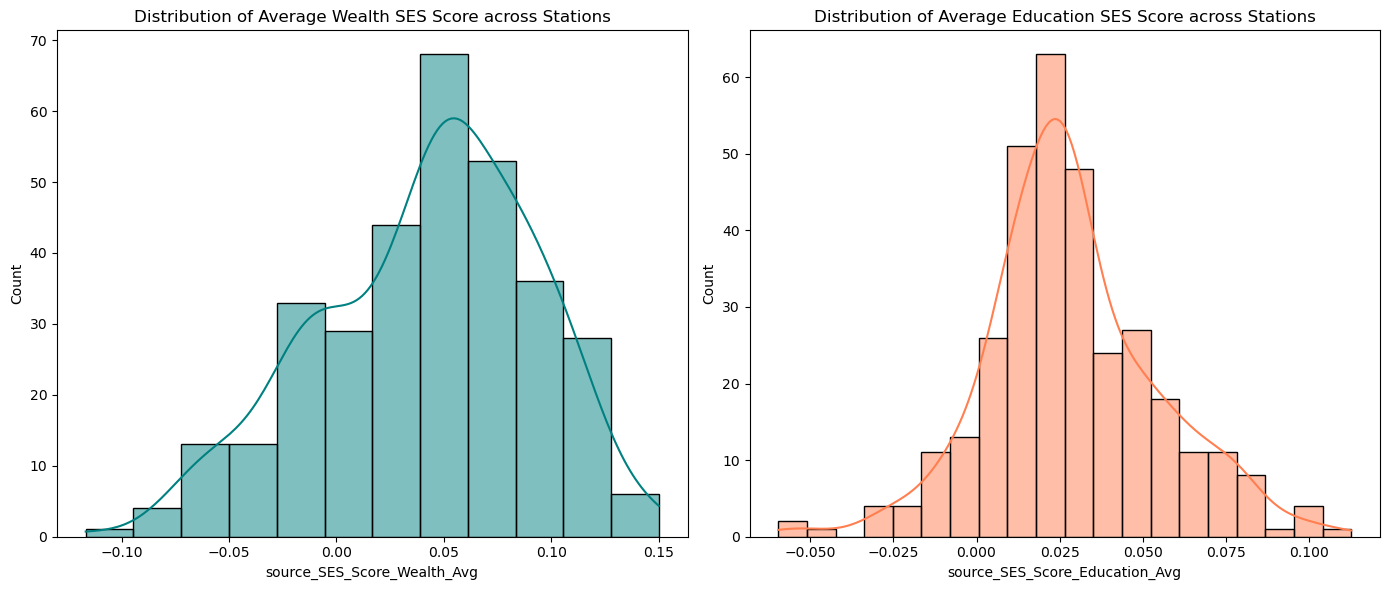

In [28]:
# Aggregate socioeconomic data by station (taking the mean as these values are usually static per station)
station_profiles = disruptions_df.groupby('source')[source_socio_cols].mean()

# Plotting the distribution of SES Wealth Score and Education Score across stations
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(station_profiles['source_SES_Score_Wealth_Avg'], kde=True, color='teal')
plt.title('Distribution of Average Wealth SES Score across Stations')

plt.subplot(1, 2, 2)
sns.histplot(station_profiles['source_SES_Score_Education_Avg'], kde=True, color='coral')
plt.title('Distribution of Average Education SES Score across Stations')

plt.tight_layout()
plt.show()

Top 10 Stations in Highest Income Areas:
source
Overveen                63.277896
Bussum Zuid             63.260107
Naarden-Bussum          62.853759
Bunnik                  62.621178
Heemstede-Aerdenhout    62.547671
Hollandsche Rading      62.140655
Bilthoven               61.851845
Heeze                   61.543641
Duivendrecht            61.334775
Houten Castellum        61.148292
Name: source_Income_Avg_Percentile_Score, dtype: float64

Bottom 10 Stations in Lowest Income Areas:
source
Kerkrade Centrum       42.212941
Maastricht Randwyck    42.681579
Eygelshoven Markt      43.035294
Harlingen              43.137500
Heerlen                43.947389
Maastricht             44.235067
Nijmegen Lent          44.958287
Enschede Kennispark    45.030159
Delft                  45.172179
Nijmegen               45.188850
Name: source_Income_Avg_Percentile_Score, dtype: float64


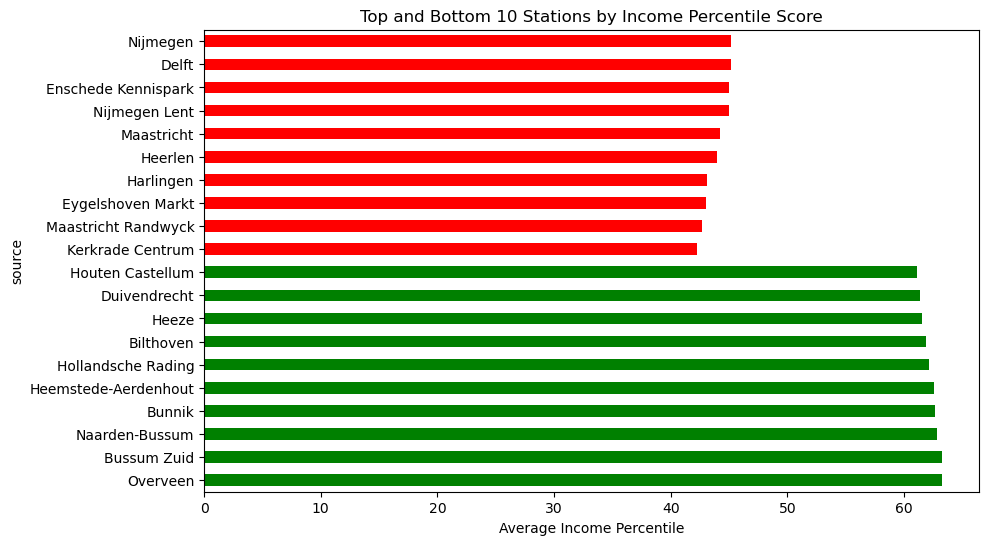

In [29]:
# Ranking stations by Wealth Percentile Score
top_wealth_stations = station_profiles['source_Income_Avg_Percentile_Score'].sort_values(ascending=False).head(10)
bottom_wealth_stations = station_profiles['source_Income_Avg_Percentile_Score'].sort_values(ascending=True).head(10)

print("Top 10 Stations in Highest Income Areas:")
print(top_wealth_stations)
print("\nBottom 10 Stations in Lowest Income Areas:")
print(bottom_wealth_stations)

# Visualize the Top vs Bottom
plt.figure(figsize=(10, 6))
pd.concat([top_wealth_stations, bottom_wealth_stations]).plot(kind='barh', color=['green']*10 + ['red']*10)
plt.title('Top and Bottom 10 Stations by Income Percentile Score')
plt.xlabel('Average Income Percentile')
plt.show()

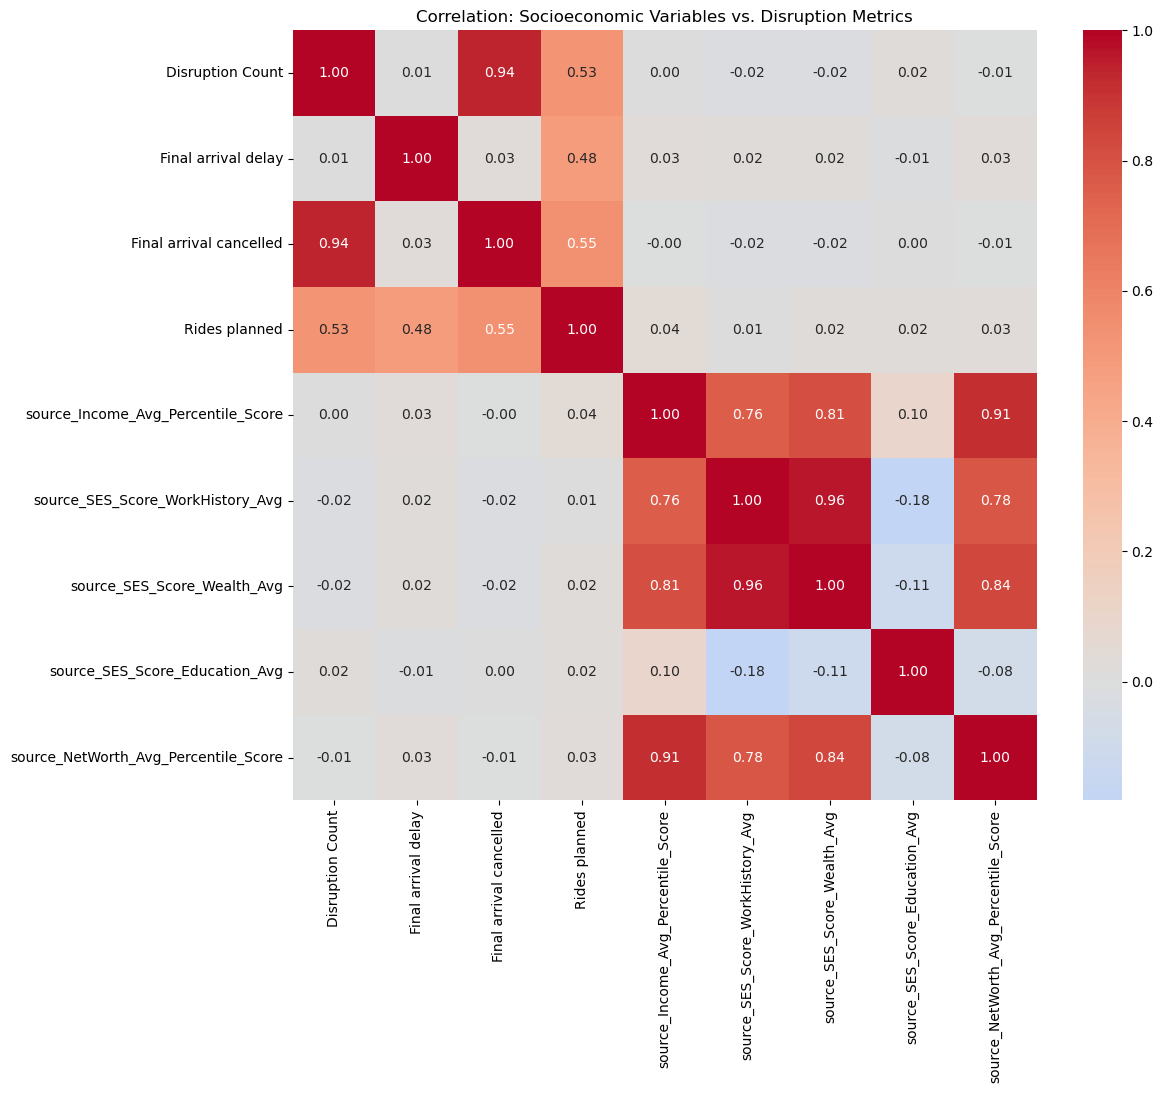

In [30]:
# Select a subset of disruption metrics and socioeconomic features
corr_cols = ['Disruption Count', 'Final arrival delay', 'Final arrival cancelled', 'Rides planned'] + \
            [col for col in source_socio_cols if 'Avg' in col or 'Score' in col]

plt.figure(figsize=(12, 10))
correlation_matrix = disruptions_df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation: Socioeconomic Variables vs. Disruption Metrics')
plt.show()

C:\Users\EduardCP\AppData\Local\Temp\ipykernel_26460\2179820387.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\EduardCP\AppData\Local\Temp\ipykernel_26460\2179820387.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




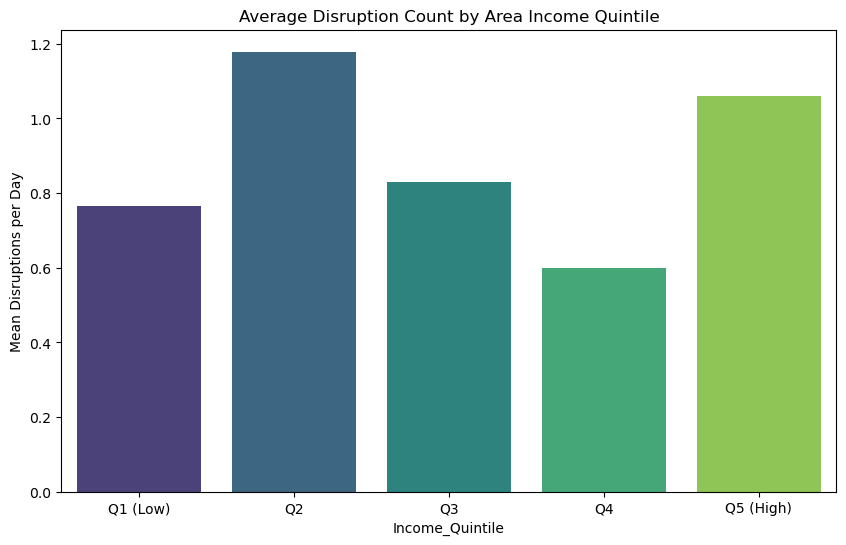

In [31]:
# Binning source stations into quintiles based on Income Percentile
disruptions_df['Income_Quintile'] = pd.qcut(disruptions_df['source_Income_Avg_Percentile_Score'], 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

# Analyze disruption count by quintile
quintile_analysis = disruptions_df.groupby('Income_Quintile')['Disruption Count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=quintile_analysis, x='Income_Quintile', y='Disruption Count', palette='viridis')
plt.title('Average Disruption Count by Area Income Quintile')
plt.ylabel('Mean Disruptions per Day')
plt.show()

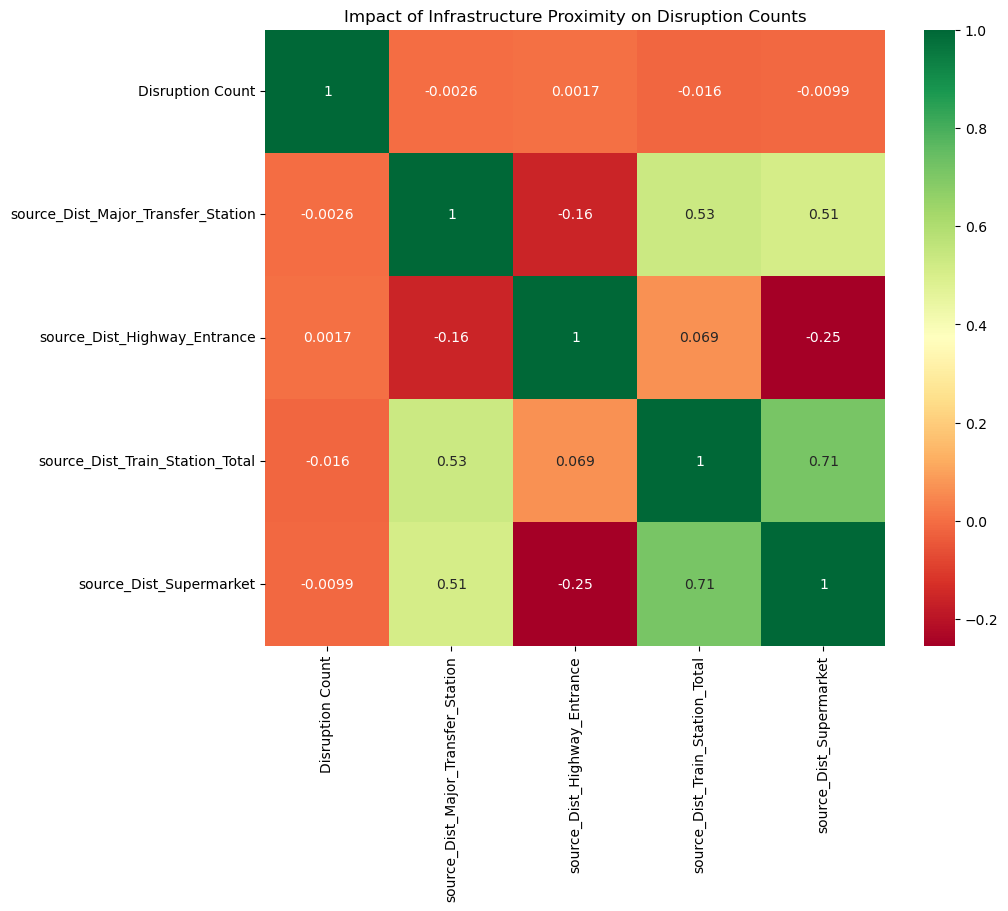

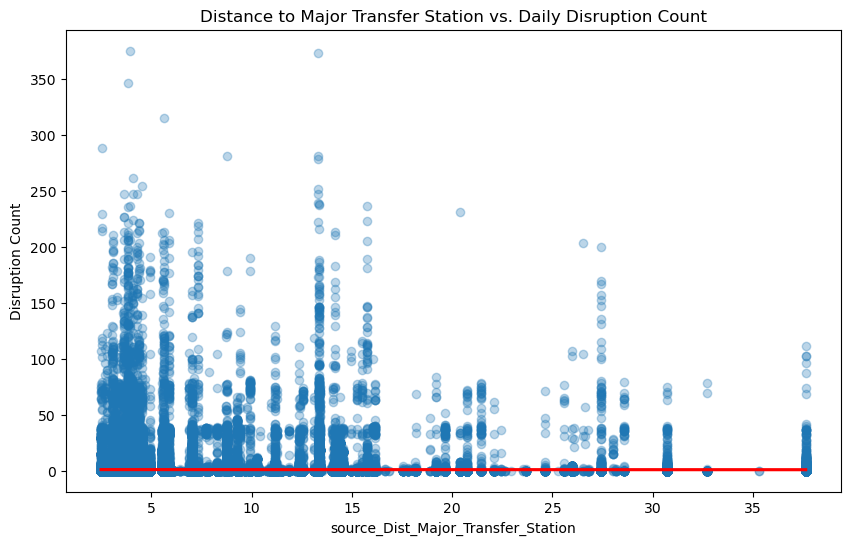

In [32]:
# Correlation between distance to infrastructure and disruptions
dist_corr_cols = ['Disruption Count', 'source_Dist_Major_Transfer_Station', 'source_Dist_Highway_Entrance', 
                  'source_Dist_Train_Station_Total', 'source_Dist_Supermarket']

plt.figure(figsize=(10, 8))
sns.heatmap(disruptions_df[dist_corr_cols].corr(), annot=True, cmap='RdYlGn')
plt.title('Impact of Infrastructure Proximity on Disruption Counts')
plt.show()

# Scatter plot: Distance to Major Transfer Station vs. Disruption Count
plt.figure(figsize=(10, 6))
sns.regplot(data=disruptions_df, x='source_Dist_Major_Transfer_Station', y='Disruption Count', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Distance to Major Transfer Station vs. Daily Disruption Count')
plt.show()

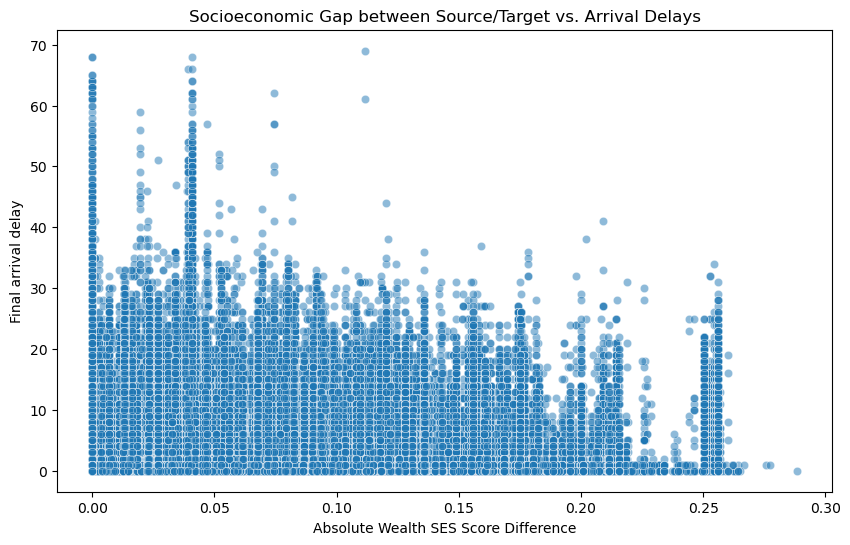

In [33]:
# Calculate the absolute difference in SES scores between source and target
disruptions_df['SES_Wealth_Gap'] = abs(disruptions_df['source_SES_Score_Wealth_Avg'] - disruptions_df['target_SES_Score_Wealth_Avg'])

# Visualize relationship with delays
plt.figure(figsize=(10, 6))
sns.scatterplot(data=disruptions_df, x='SES_Wealth_Gap', y='Final arrival delay', alpha=0.5)
plt.title('Socioeconomic Gap between Source/Target vs. Arrival Delays')
plt.xlabel('Absolute Wealth SES Score Difference')
plt.show()

In [34]:
import folium
from folium.plugins import MarkerCluster

# 1. Prepare station data (averaging coordinates and SES scores)
# Note: You'll need the coordinates_df from your earlier cells
station_geo = disruptions_df.groupby('source').agg({
    'source_SES_Score_Wealth_Avg': 'mean',
    'Disruption Count': 'sum'
}).reset_index()

# Merge with your coordinates data
# Assuming coordinates_df has columns: 'station', 'lat', 'lng'
station_geo = station_geo.merge(coordinates_df, left_on='source', right_on='name_long')

# 2. Initialize Map (centered on the Netherlands)
m = folium.Map(location=[52.1326, 5.2913], zoom_start=8, tiles='cartodbpositron')

# 3. Add Stations as Circles
for _, row in station_geo.iterrows():
    # Color coding based on Wealth SES (Red = Low, Green = High)
    color = 'red' if row['source_SES_Score_Wealth_Avg'] < 0 else 'green'
    
    folium.CircleMarker(
        location=[row['geo_lat'], row['geo_lng']],
        radius=5 + (row['Disruption Count'] / 100), # Size based on total disruptions
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Station: {row['source']}<br>Wealth SES: {row['source_SES_Score_Wealth_Avg']:.2f}<br>Total Disruptions: {row['Disruption Count']}"
    ).add_to(m)

# 4. Add Trajectories (Edges)
# Focus on the top 50 most disrupted routes to keep the map readable
top_routes = disruptions_df.groupby(['source', 'target'])['Disruption Count'].sum().nlargest(50).reset_index()

for _, route in top_routes.iterrows():
    # Get coordinates for source and target
    src_coords = coordinates_df[coordinates_df['name_long'] == route['source']][['geo_lat', 'geo_lng']].values
    tgt_coords = coordinates_df[coordinates_df['name_long'] == route['target']][['geo_lat', 'geo_lng']].values
    
    if len(src_coords) > 0 and len(tgt_coords) > 0:
        folium.PolyLine(
            locations=[src_coords[0], tgt_coords[0]],
            weight=route['Disruption Count'] / 20, # Thickness based on disruption frequency
            color='blue',
            opacity=0.4,
            popup=f"{route['source']} to {route['target']}: {route['Disruption Count']} disruptions"
        ).add_to(m)

m.save('station_socioeconomic_map.html')
# Save the map
m.save('temp_map.html')

# Get the full path and open in your default browser
full_path = os.path.abspath('temp_map.html')
import webbrowser
webbrowser.open('file://' + full_path)

True

In [35]:
import statsmodels.api as sm

# We want to see which station characteristics predict high disruption counts
# Filter for source-based variables only
analysis_df = disruptions_df.groupby('source').agg({
    'Disruption Count': 'sum',
    'source_SES_Score_Wealth_Avg': 'mean',
    'source_SES_Score_Education_Avg': 'mean',
    'source_Dist_Major_Transfer_Station': 'mean',
    'source_WorkHistory_NotEmployed_Last4Y_pct': 'mean'
}).dropna()

# Define Dependent (Y) and Independent (X) variables
y = analysis_df['Disruption Count']
X = analysis_df.drop(columns=['Disruption Count'])
X = sm.add_constant(X) # Add intercept

model = sm.OLS(y, X).fit()

print("--- Socioeconomic Impact on Disruption Frequency ---")
print(model.summary())

--- Socioeconomic Impact on Disruption Frequency ---
                            OLS Regression Results                            
Dep. Variable:       Disruption Count   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     6.993
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.07e-05
Time:                        21:28:13   Log-Likelihood:                -3215.2
No. Observations:                 328   AIC:                             6440.
Df Residuals:                     323   BIC:                             6459.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

In [36]:
# Select a sample of the new socioeconomic and infrastructure columns
socio_cols = [col for col in disruptions_df.columns if 'source_' in col or 'target_' in col]
dist_cols = [col for col in disruptions_df.columns if 'Dist_' in col]

# Provide summary statistics for these variables
print("--- Socioeconomic Variable Summary ---")
print(disruptions_df[socio_cols + dist_cols].describe().T[['mean', 'min', 'max', '50%']])

# Check for missing data in these specific fields
print("\n--- Missing Values Check ---")
print(disruptions_df[socio_cols + dist_cols].isnull().sum()[disruptions_df[socio_cols + dist_cols].isnull().sum() > 0])

--- Socioeconomic Variable Summary ---
                                                        mean         min  \
source_WorkHistory_NotEmployed_Last4Y_pct           6.328262    1.083333   
source_WorkHistory_ConstantlyEmployed_Last4Y_pct   52.496732   39.931579   
source_WorkHistory_Retired_pct                     25.595298   14.253846   
source_Wealth_Percentile_1_40_pct                  39.585571   16.083333   
source_Income_Avg_Percentile_Score                 51.228993   41.397917   
source_Edu_Low_pct                                 19.218543   11.814444   
source_Edu_High_Total_pct                          36.286177   23.047059   
source_PrivateHouseholds_Count                    990.056780  141.228070   
source_SES_Score_WorkHistory_Avg                    0.007650   -0.113559   
source_SES_Score_Wealth_Avg                         0.010366   -0.132103   
source_SES_Score_Education_Avg                      0.036970   -0.079765   
source_NetWorth_Avg_Percentile_Score             

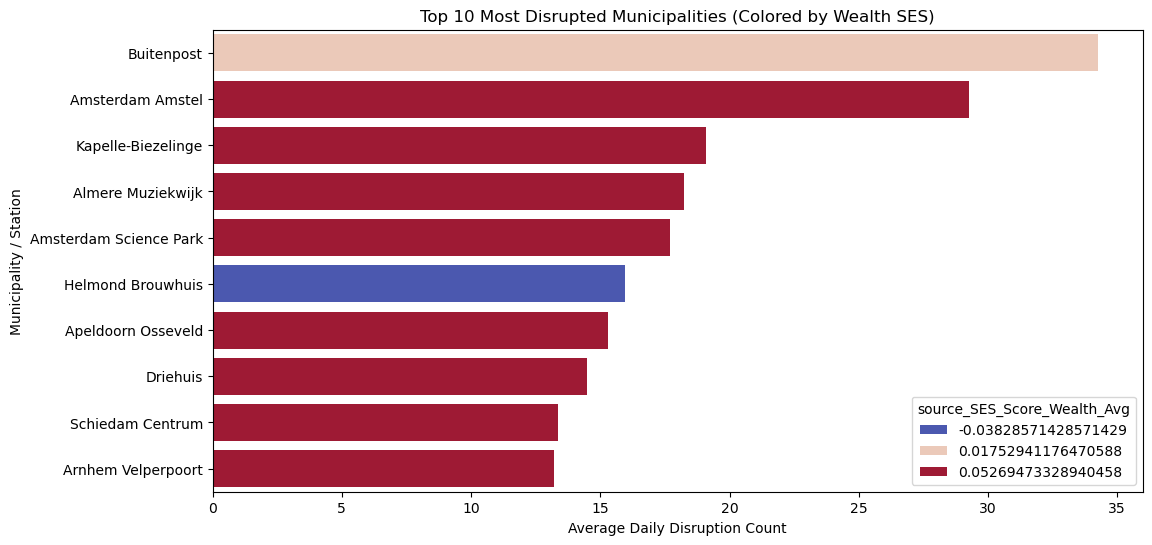

In [37]:
# Grouping by source (municipality/station) to find the 'Least Reliable' municipalities
municipality_reliability = disruptions_df.groupby('source').agg({
    'Disruption Count': 'mean',
    'source_SES_Score_Wealth_Avg': 'first', # It's the same for all rows of a municipality
    'Rides planned': 'sum'
}).reset_index()

# Filter for municipalities with a significant number of rides to avoid outliers
municipality_reliability = municipality_reliability[municipality_reliability['Rides planned'] > 500]

# Sorting by most disruptions
top_disrupted_mun = municipality_reliability.sort_values(by='Disruption Count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_disrupted_mun, x='Disruption Count', y='source', hue='source_SES_Score_Wealth_Avg', palette='coolwarm')
plt.title('Top 10 Most Disrupted Municipalities (Colored by Wealth SES)')
plt.xlabel('Average Daily Disruption Count')
plt.ylabel('Municipality / Station')
plt.show()

<Figure size 1000x600 with 0 Axes>

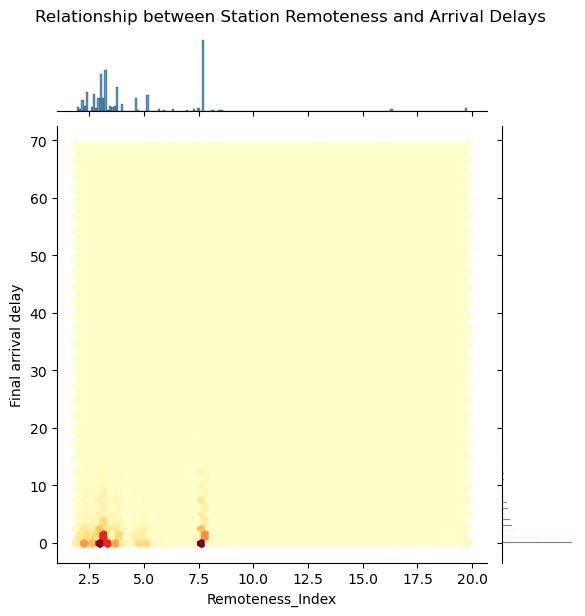

In [38]:
# Create a proxy for 'Remoteness'
disruptions_df['Remoteness_Index'] = (disruptions_df['source_Dist_Highway_Entrance'] + 
                                       disruptions_df['source_Dist_Major_Transfer_Station']) / 2

# Plotting Remoteness vs. Delay
plt.figure(figsize=(10, 6))
sns.jointplot(data=disruptions_df, x='Remoteness_Index', y='Final arrival delay', kind='hex', cmap='YlOrRd')
plt.suptitle('Relationship between Station Remoteness and Arrival Delays', y=1.02)
plt.show()